In [ ]:
!pip -q install SimpleITK tqdm

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 20.9 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
import os, glob

BASE = "/content/drive/MyDrive/Practical4/LUNA16"
SUBSETS_DIR = os.path.join(BASE, "subsets")

subset_ids = [0,1,2]

mhd_paths = []

for sid in subset_ids:
    mhd_paths += glob.glob(
        os.path.join(SUBSETS_DIR, f"subset{sid}", f"subset{sid}", "*.mhd")
    )

print("Num scans:", len(mhd_paths))
print("Example:", mhd_paths[:3])

Num scans: 267
Example: ['/content/drive/MyDrive/Practical4/LUNA16/subsets/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd', '/content/drive/MyDrive/Practical4/LUNA16/subsets/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd', '/content/drive/MyDrive/Practical4/LUNA16/subsets/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059.mhd']


In [ ]:
import os

uid2path = {}
for p in mhd_paths:
    uid = os.path.basename(p).replace(".mhd","")
    uid2path[uid] = p

print("Indexed series:", len(uid2path))
print("Example uid:", next(iter(uid2path.keys())))

Indexed series: 267
Example uid: 1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260


In [ ]:
import pandas as pd
import os

CAND_CSV = os.path.join(BASE, "candidates.csv")
cand = pd.read_csv(CAND_CSV)

cand = cand[cand["seriesuid"].isin(uid2path.keys())].reset_index(drop=True)

print("Candidates in subset012:", cand.shape)
print(cand["class"].value_counts())
cand.head()

Candidates in subset012: (166001, 5)
class
0    165568
1       433
Name: count, dtype: int64


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-76.62,156.53,-529.43,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,120.13,160.73,-404.68,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,94.23,171.24,-392.76,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,74.62,190.84,-534.34,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-6.60,189.44,-469.16,0


In [ ]:
NEG_POS_RATIO = 5

pos = cand[cand["class"] == 1]
neg = cand[cand["class"] == 0]

neg_keep = min(len(neg), len(pos) * NEG_POS_RATIO)
neg = neg.sample(n=neg_keep, random_state=42)

cand_bal = pd.concat([pos, neg], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced:", cand_bal["class"].value_counts(), "Total:", len(cand_bal))

Balanced: class
0    2165
1     433
Name: count, dtype: int64 Total: 2598


In [ ]:
import numpy as np
import SimpleITK as sitk

def load_scan(mhd_path):
    itk = sitk.ReadImage(mhd_path)
    vol_zyx = sitk.GetArrayFromImage(itk).astype(np.float32)  # (z,y,x)

    origin_xyz  = np.array(itk.GetOrigin(), dtype=np.float32)   # (x,y,z)
    spacing_xyz = np.array(itk.GetSpacing(), dtype=np.float32)  # (x,y,z)
    return vol_zyx, origin_xyz, spacing_xyz

def world_to_voxel_xyz(world_xyz, origin_xyz, spacing_xyz):
    return (world_xyz - origin_xyz) / spacing_xyz  # (x,y,z)

def normalize_hu(vol):
    minb, maxb = -1000.0, 400.0
    vol = np.clip(vol, minb, maxb)
    vol = (vol - minb) / (maxb - minb)
    return vol.astype(np.float32)

def crop_patch_zyx(vol, center_zyx, size=32):
    z, y, x = center_zyx
    r = size // 2

    z1, z2 = z-r, z+r
    y1, y2 = y-r, y+r
    x1, x2 = x-r, x+r

    # pad nếu vượt biên
    pad_z1 = max(0, -z1); pad_z2 = max(0, z2 - vol.shape[0])
    pad_y1 = max(0, -y1); pad_y2 = max(0, y2 - vol.shape[1])
    pad_x1 = max(0, -x1); pad_x2 = max(0, x2 - vol.shape[2])

    if any([pad_z1,pad_z2,pad_y1,pad_y2,pad_x1,pad_x2]):
        vol = np.pad(
            vol,
            ((pad_z1,pad_z2),(pad_y1,pad_y2),(pad_x1,pad_x2)),
            mode="constant",
            constant_values=-1000.0
        )
        z += pad_z1; y += pad_y1; x += pad_x1
        z1, z2 = z-r, z+r
        y1, y2 = y-r, y+r
        x1, x2 = x-r, x+r

    patch = vol[z1:z2, y1:y2, x1:x2]
    return patch

In [ ]:

!mkdir -p /content/LUNA16_local/subsets

!cp -r "/content/drive/MyDrive/Practical4/LUNA16/subsets/subset0" /content/LUNA16_local/subsets/
!cp -r "/content/drive/MyDrive/Practical4/LUNA16/subsets/subset1" /content/LUNA16_local/subsets/
!cp -r "/content/drive/MyDrive/Practical4/LUNA16/subsets/subset2" /content/LUNA16_local/subsets/

In [ ]:
BASE_LOCAL = "/content/LUNA16_local"
SUBSETS_DIR = f"{BASE_LOCAL}/subsets"

In [ ]:
import glob, os

BASE_LOCAL = "/content/LUNA16_local"
SUBSETS_DIR_LOCAL = os.path.join(BASE_LOCAL, "subsets")

mhd_paths = []
for sid in [0,1,2]:
    mhd_paths += glob.glob(os.path.join(SUBSETS_DIR_LOCAL, f"subset{sid}", "**", "*.mhd"), recursive=True)

print("Num local scans:", len(mhd_paths))
print("Example:", mhd_paths[:2])

uid2path = {os.path.basename(p).replace(".mhd",""): p for p in mhd_paths}
print("Indexed uids:", len(uid2path))

Num local scans: 267
Example: ['/content/LUNA16_local/subsets/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.724251104254976962355686318345.mhd', '/content/LUNA16_local/subsets/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931778258890371755354.mhd']
Indexed uids: 267


In [ ]:
import pandas as pd, os

BASE_DRIVE = "/content/drive/MyDrive/Practical4/LUNA16"
CAND_CSV = os.path.join(BASE_DRIVE, "candidates.csv")

cand = pd.read_csv(CAND_CSV)
cand = cand[cand["seriesuid"].isin(uid2path.keys())].reset_index(drop=True)

print("Candidates in subset012:", cand.shape)
print(cand["class"].value_counts())

Candidates in subset012: (166001, 5)
class
0    165568
1       433
Name: count, dtype: int64


In [ ]:
NEG_POS_RATIO = 5

pos = cand[cand["class"] == 1]
neg = cand[cand["class"] == 0]

neg_keep = min(len(neg), len(pos) * NEG_POS_RATIO)
neg = neg.sample(n=neg_keep, random_state=42)

cand_bal = pd.concat([pos, neg], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
print("Balanced:", cand_bal["class"].value_counts(), "Total:", len(cand_bal))

Balanced: class
0    2165
1     433
Name: count, dtype: int64 Total: 2598


In [ ]:
import SimpleITK as sitk
import numpy as np

def load_scan(mhd_path):

    itk = sitk.ReadImage(mhd_path)


    vol = sitk.GetArrayFromImage(itk).astype(np.float32)


    origin = np.array(itk.GetOrigin(), dtype=np.float32)
    spacing = np.array(itk.GetSpacing(), dtype=np.float32)

    return vol, origin, spacing

In [ ]:
import numpy as np

def crop_patch_zyx(vol, center, size=32):

    z, y, x = center
    r = size // 2

    z1, z2 = z-r, z+r
    y1, y2 = y-r, y+r
    x1, x2 = x-r, x+r


    pad_z1 = max(0, -z1)
    pad_z2 = max(0, z2 - vol.shape[0])

    pad_y1 = max(0, -y1)
    pad_y2 = max(0, y2 - vol.shape[1])

    pad_x1 = max(0, -x1)
    pad_x2 = max(0, x2 - vol.shape[2])

    if pad_z1 or pad_z2 or pad_y1 or pad_y2 or pad_x1 or pad_x2:

        vol = np.pad(
            vol,
            ((pad_z1, pad_z2),
             (pad_y1, pad_y2),
             (pad_x1, pad_x2)),
            mode="constant",
            constant_values=-1000
        )

        z += pad_z1
        y += pad_y1
        x += pad_x1

        z1, z2 = z-r, z+r
        y1, y2 = y-r, y+r
        x1, x2 = x-r, x+r

    patch = vol[z1:z2, y1:y2, x1:x2]

    return patch

In [ ]:
def normalize_hu(vol):

    min_hu = -1000
    max_hu = 400

    vol = np.clip(vol, min_hu, max_hu)
    vol = (vol - min_hu) / (max_hu - min_hu)

    return vol.astype(np.float32)

In [ ]:
import numpy as np
from tqdm import tqdm

PATCH_SIZE = 32

def build_patches_groupby(df, uid2path, patch_size=32):
    X_list, y_list = [], []

    for uid, g in tqdm(df.groupby("seriesuid"), total=df["seriesuid"].nunique()):
        vol, origin, spacing = load_scan(uid2path[uid])  # load 1 lần/scan

        coords = g[["coordX","coordY","coordZ"]].values.astype(np.float32)  # world xyz
        labels = g["class"].values.astype(np.int64)

        # world -> voxel (vectorized)
        v_xyz = (coords - origin[None, :]) / spacing[None, :]
        v_xyz = np.rint(v_xyz).astype(np.int32)

        for (cx, cy, cz), lab in zip(v_xyz, labels):
            patch = crop_patch_zyx(vol, (cz, cy, cx), size=patch_size)
            patch = normalize_hu(patch)
            X_list.append(patch)
            y_list.append(lab)

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=np.int64)
    return X, y

X, y = build_patches_groupby(cand_bal, uid2path, patch_size=PATCH_SIZE)
print("X:", X.shape, "y:", y.shape, "pos:", int(y.sum()))

100%|██████████| 267/267 [03:58<00:00,  1.12it/s]

X: (2598, 32, 32, 32) y: (2598,) pos: 433


In [ ]:
from sklearn.model_selection import train_test_split
import os, numpy as np

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

OUT_DIR = "/content/drive/MyDrive/Practical4/LUNA16/prepared_subset012_ps32"
os.makedirs(OUT_DIR, exist_ok=True)

np.save(os.path.join(OUT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(OUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUT_DIR, "X_val.npy"), X_val)
np.save(os.path.join(OUT_DIR, "y_val.npy"), y_val)

print("Saved to:", OUT_DIR)
print("Train:", X_train.shape, "pos:", int(y_train.sum()))
print("Val  :", X_val.shape, "pos:", int(y_val.sum()))

Saved to: /content/drive/MyDrive/Practical4/LUNA16/prepared_subset012_ps32
Train: (2078, 32, 32, 32) pos: 346
Val  : (520, 32, 32, 32) pos: 87


In [ ]:
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class LunaPatchDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().unsqueeze(1)  # (N,1,32,32,32)
        self.y = torch.from_numpy(y).float()               # (N,)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = LunaPatchDataset(X_train, y_train)
val_ds   = LunaPatchDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(next(iter(train_loader))[0].shape)  # should be (B,1,32,32,32)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([32, 1, 32, 32, 32])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Simple3DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv3d(1, 16, 3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.MaxPool3d(2)  # 16x16x16
        )
        self.conv2 = nn.Sequential(
            nn.Conv3d(16, 32, 3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2)  # 8x8x8
        )
        self.conv3 = nn.Sequential(
            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(2)  # 4x4x4
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4*4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.head(x)
        return x.squeeze(1)  # logits

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Simple3DCNN().to(device)
print("device:", device)

device: cpu


In [ ]:
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("pos_weight:", pos_weight.item())

pos_weight: 5.005780220031738


In [ ]:
import torch, os
from tqdm import tqdm

SAVE_DIR = "/content/drive/MyDrive/Practical4/LUNA16/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
CKPT_PATH = os.path.join(SAVE_DIR, "simple3dcnn_subset012_ps32_best.pt")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    tp=fp=tn=fn=0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * Xb.size(0)

            prob = torch.sigmoid(logits)
            pred = (prob >= 0.5).float()

            total += Xb.size(0)
            correct += (pred == yb).sum().item()

            tp += ((pred==1) & (yb==1)).sum().item()
            tn += ((pred==0) & (yb==0)).sum().item()
            fp += ((pred==1) & (yb==0)).sum().item()
            fn += ((pred==0) & (yb==1)).sum().item()

    acc = correct/total
    prec = tp/(tp+fp+1e-9)
    rec  = tp/(tp+fn+1e-9)
    f1   = 2*prec*rec/(prec+rec+1e-9)
    return total_loss/total, acc, prec, rec, f1

best_f1 = -1

EPOCHS = 10
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0

    for Xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * Xb.size(0)

    train_loss = running / len(train_ds)
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(model, val_loader)

    print(f"[{epoch}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| acc={val_acc:.3f} prec={val_prec:.3f} rec={val_rec:.3f} f1={val_f1:.3f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_f1": best_f1,
            "pos_weight": pos_weight.item(),
            "patch_size": 32
        }, CKPT_PATH)
        print("✅ Saved best checkpoint:", CKPT_PATH)

Epoch 1/10:   0%|          | 0/65 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/10: 100%|██████████| 65/65 [00:54<00:00,  1.18it/s]


[1] train_loss=1.3592 | val_loss=1.0397 | acc=0.512 prec=0.240 rec=0.885 f1=0.377
✅ Saved best checkpoint: /content/drive/MyDrive/Practical4/LUNA16/checkpoints/simple3dcnn_subset012_ps32_best.pt


Epoch 2/10: 100%|██████████| 65/65 [00:50<00:00,  1.28it/s]


[2] train_loss=0.9231 | val_loss=0.9606 | acc=0.860 prec=0.617 rec=0.425 f1=0.503
✅ Saved best checkpoint: /content/drive/MyDrive/Practical4/LUNA16/checkpoints/simple3dcnn_subset012_ps32_best.pt


Epoch 3/10: 100%|██████████| 65/65 [00:57<00:00,  1.14it/s]


...

[8] train_loss=0.3255 | val_loss=0.5884 | acc=0.869 prec=0.571 rec=0.874 f1=0.691


Epoch 9/10: 100%|██████████| 65/65 [00:52<00:00,  1.23it/s]


[9] train_loss=0.2517 | val_loss=0.7250 | acc=0.887 prec=0.623 rec=0.816 f1=0.706
✅ Saved best checkpoint: /content/drive/MyDrive/Practical4/LUNA16/checkpoints/simple3dcnn_subset012_ps32_best.pt


Epoch 10/10: 100%|██████████| 65/65 [00:51<00:00,  1.25it/s]


[10] train_loss=0.2306 | val_loss=0.6995 | acc=0.902 prec=0.673 rec=0.805 f1=0.733
✅ Saved best checkpoint: /content/drive/MyDrive/Practical4/LUNA16/checkpoints/simple3dcnn_subset012_ps32_best.pt


=== SAMPLE OUTPUT ===
y_true: 0
logit : -6.333550453186035
prob  : 0.0017725704237818718
y_pred: 0


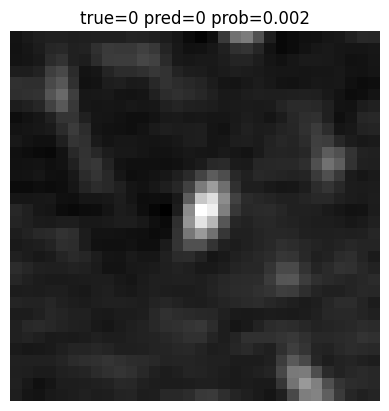

In [ ]:
import torch, numpy as np
import matplotlib.pyplot as plt

CKPT_PATH = "/content/drive/MyDrive/Practical4/LUNA16/checkpoints/simple3dcnn_subset012_ps32_best.pt"

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

i = 0
x = torch.from_numpy(X_val[i]).float().unsqueeze(0).unsqueeze(0).to(device)  # (1,1,32,32,32)
y_true = int(y_val[i])

with torch.no_grad():
    logit = model(x).item()
    prob = float(torch.sigmoid(torch.tensor(logit)).item())

y_pred = 1 if prob >= 0.5 else 0

print("=== SAMPLE OUTPUT ===")
print("y_true:", y_true)
print("logit :", logit)
print("prob  :", prob)
print("y_pred:", y_pred)

# show middle slice
patch = X_val[i]
plt.imshow(patch[PATCH_SIZE//2], cmap="gray")
plt.title(f"true={y_true} pred={y_pred} prob={prob:.3f}")
plt.axis("off")
plt.show()

In [ ]:
import torch

CKPT_PATH = "/content/drive/MyDrive/Practical4/LUNA16/checkpoints/simple3dcnn_subset012_ps32_best.pt"

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

print("Loaded checkpoint epoch:", ckpt["epoch"])

Loaded checkpoint epoch: 10


In [ ]:
import random

uid = random.choice(list(uid2path.keys()))
print("Selected scan:", uid)

scan_candidates = cand[cand["seriesuid"] == uid]
print("Num candidates:", len(scan_candidates))

Selected scan: 1.3.6.1.4.1.14519.5.2.1.6279.6001.216882370221919561230873289517
Num candidates: 297


In [ ]:
import numpy as np

def world_to_voxel_xyz(world_xyz, origin_xyz, spacing_xyz):

    world_xyz = np.array(world_xyz)
    origin_xyz = np.array(origin_xyz)
    spacing_xyz = np.array(spacing_xyz)

    voxel_xyz = (world_xyz - origin_xyz) / spacing_xyz

    return voxel_xyz

In [ ]:
import numpy as np
import torch

vol, origin, spacing = load_scan(uid2path[uid])

results = []

for _, row in scan_candidates.iterrows():

    xw = float(row["coordX"])
    yw = float(row["coordY"])
    zw = float(row["coordZ"])

    v_xyz = world_to_voxel_xyz(np.array([xw,yw,zw]), origin, spacing)

    cx, cy, cz = np.round(v_xyz).astype(int)

    patch = crop_patch_zyx(vol,(cz,cy,cx),32)
    patch = normalize_hu(patch)

    x = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        logit = model(x)
        prob = torch.sigmoid(logit).item()

    results.append({
        "coord":(cx,cy,cz),
        "prob":prob
    })

print("Predictions:", len(results))

Predictions: 297


In [ ]:
threshold = 0.7

detections = [r for r in results if r["prob"] > threshold]

print("Detected nodules:", len(detections))

for d in detections[:5]:
    print(d)

Detected nodules: 23
{'coord': (np.int64(232), np.int64(280), np.int64(104)), 'prob': 0.7983084321022034}
{'coord': (np.int64(424), np.int64(200), np.int64(176)), 'prob': 0.7976011037826538}
{'coord': (np.int64(340), np.int64(139), np.int64(206)), 'prob': 0.8261063098907471}
{'coord': (np.int64(460), np.int64(221), np.int64(105)), 'prob': 0.910531759262085}
{'coord': (np.int64(412), np.int64(221), np.int64(214)), 'prob': 0.9959471821784973}


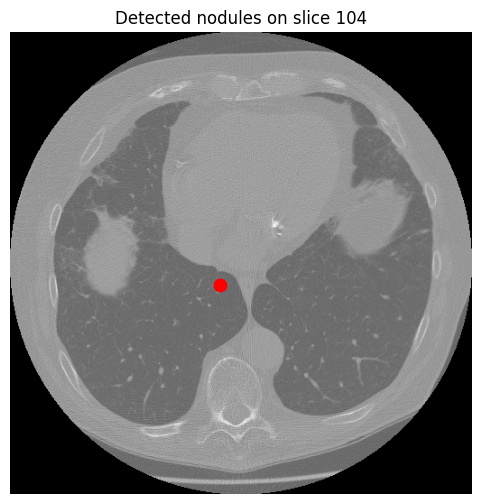

In [ ]:
import matplotlib.pyplot as plt

z = detections[0]["coord"][2]

plt.figure(figsize=(6,6))
plt.imshow(vol[z], cmap="gray")

for d in detections:
    x,y,z0 = d["coord"]

    if z0 == z:
        plt.scatter(x,y,c='red',s=80)

plt.title(f"Detected nodules on slice {z}")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
import torch

def eval_with_threshold(model, loader, thr=0.5):
    model.eval()
    tp=fp=tn=fn=0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            logits = model(Xb)
            prob = torch.sigmoid(logits)
            pred = (prob >= thr).float()

            tp += ((pred==1) & (yb==1)).sum().item()
            tn += ((pred==0) & (yb==0)).sum().item()
            fp += ((pred==1) & (yb==0)).sum().item()
            fn += ((pred==0) & (yb==1)).sum().item()

    prec = tp/(tp+fp+1e-9)
    rec  = tp/(tp+fn+1e-9)
    f1   = 2*prec*rec/(prec+rec+1e-9)
    acc  = (tp+tn)/(tp+tn+fp+fn+1e-9)
    return acc, prec, rec, f1, (tp,fp,tn,fn)

for thr in [0.3, 0.5, 0.7]:
    acc, prec, rec, f1, cm = eval_with_threshold(model, val_loader, thr=thr)
    print(f"thr={thr:.1f} acc={acc:.3f} prec={prec:.3f} rec={rec:.3f} f1={f1:.3f} cm(tp,fp,tn,fn)={cm}")

thr=0.3 acc=0.890 prec=0.627 rec=0.851 f1=0.722 cm(tp,fp,tn,fn)=(74, 44, 389, 13)
thr=0.5 acc=0.902 prec=0.673 rec=0.805 f1=0.733 cm(tp,fp,tn,fn)=(70, 34, 399, 17)
thr=0.7 acc=0.921 prec=0.829 rec=0.667 f1=0.739 cm(tp,fp,tn,fn)=(58, 12, 421, 29)


In [ ]:
import torch
import numpy as np
import pandas as pd

def eval_metrics(model, loader, threshold=0.5, device="cpu"):
    model.eval()
    tp=fp=tn=fn=0
    total_loss = 0.0
    n = 0

    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            prob = torch.sigmoid(logits)
            pred = (prob >= threshold).float()

            tp += ((pred==1) & (yb==1)).sum().item()
            tn += ((pred==0) & (yb==0)).sum().item()
            fp += ((pred==1) & (yb==0)).sum().item()
            fn += ((pred==0) & (yb==1)).sum().item()

            n += Xb.size(0)

    acc  = (tp+tn) / (tp+tn+fp+fn+1e-9)
    prec = tp / (tp+fp+1e-9)
    rec  = tp / (tp+fn+1e-9)
    f1   = 2*prec*rec / (prec+rec+1e-9)

    return {
        "threshold": threshold,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "n": tp+fp+tn+fn
    }

In [ ]:
thresholds = [0.3, 0.5, 0.7]
rows = []
for thr in thresholds:
    rows.append(eval_metrics(model, val_loader, threshold=thr, device=device))

df_thr = pd.DataFrame(rows)
df_thr

,threshold,acc,precision,recall,f1,tp,fp,tn,fn,n
0,0.3,0.890385,0.627119,0.850575,0.721951,74,44,389,13,520
1,0.5,0.901923,0.673077,0.804598,0.732984,70,34,399,17,520
2,0.7,0.921154,0.828571,0.666667,0.738854,58,12,421,29,520


In [ ]:
import torch.nn as nn
from tqdm import tqdm
import copy

def train_one_experiment(lr=1e-3, epochs=8, threshold=0.5):
    model = Simple3DCNN().to(device)

    # pos_weight từ y_train (bạn đã tính trước)
    pos = y_train.sum()
    neg = len(y_train) - pos
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best = {"f1": -1}
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        for Xb, yb in tqdm(train_loader, desc=f"lr={lr} ep={ep}/{epochs}", leave=False):
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        # evaluate
        m = eval_metrics(model, val_loader, threshold=threshold, device=device)
        if m["f1"] > best["f1"]:
            best = m
            best_state = copy.deepcopy(model.state_dict())

    # load best state lại (optional)
    model.load_state_dict(best_state)
    return best

In [ ]:
lrs = [1e-3, 3e-4, 1e-4]   # bạn chọn 2 cái cũng được
rows = []
for lr in lrs:
    best = train_one_experiment(lr=lr, epochs=8, threshold=0.5)
    best["lr"] = lr
    rows.append(best)

df_lr = pd.DataFrame(rows)[["lr","threshold","acc","precision","recall","f1","tp","fp","tn","fn"]]
df_lr.sort_values("f1", ascending=False)

lr=0.001 ep=1/8:   0%|          | 0/65 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,lr,threshold,acc,precision,recall,f1,tp,fp,tn,fn
0,0.0010,0.5,0.913462,0.728261,0.770115,0.748603,67,25,408,20
1,0.0003,0.5,0.913462,0.769231,0.689655,0.727273,60,18,415,27
2,0.0001,0.5,0.851923,0.536765,0.839080,0.654709,73,63,370,14
